In [33]:
import pandas as pd
import matplotlib.pyplot as plt

In [34]:
file_path = "Data_RHS.xlsx" 
df = pd.read_excel(file_path)
# Display the first few rows of the DataFrame
print(df.head())

         Date         Time  RHS Steps Running
0  23/03/2026  07:00:00 am                0.0
1  23/03/2026  07:00:00 am                0.0
2  23/03/2026  07:00:01 am                0.0
3  23/03/2026  07:00:01 am                0.0
4  23/03/2026  07:00:02 am                0.0


In [35]:
df = df.rename(columns={"RHS Steps Running": "Value"})
print(df.head())

         Date         Time  Value
0  23/03/2026  07:00:00 am    0.0
1  23/03/2026  07:00:00 am    0.0
2  23/03/2026  07:00:01 am    0.0
3  23/03/2026  07:00:01 am    0.0
4  23/03/2026  07:00:02 am    0.0


In [36]:
# Clean column names
df.columns = df.columns.str.strip()
df

,Date,Time,Value
0,23/03/2026,07:00:00 am,0.0
1,23/03/2026,07:00:00 am,0.0
2,23/03/2026,07:00:01 am,0.0
3,23/03/2026,07:00:01 am,0.0
4,23/03/2026,07:00:02 am,0.0
...,...,...,...
156355,24/03/2026,06:59:57 am,0.0
156356,24/03/2026,06:59:57 am,0.0
156357,24/03/2026,06:59:58 am,0.0
156358,24/03/2026,06:59:59 am,0.0


In [37]:
df
df['Datetime'] = pd.to_datetime(
    df['Date'] + ' ' + df['Time'],
    format='%d/%m/%Y %I:%M:%S %p'
)

In [24]:
df['Datetime'] = pd.to_datetime(
    df['Date'] + ' ' + df['Time'],
    format='mixed',
    dayfirst=True
)

In [25]:
df[df['Datetime'].isna()]

,Date,Time,Value,Datetime


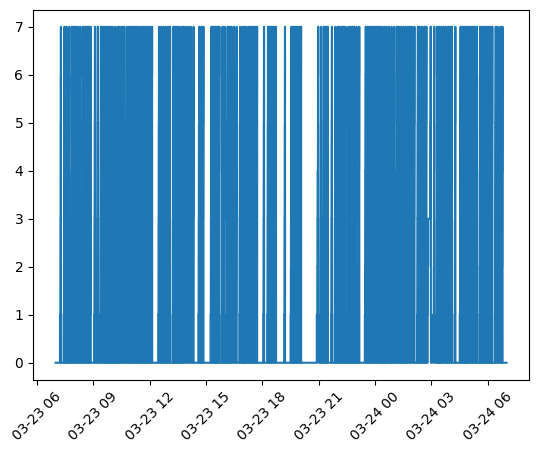

In [26]:
plt.step(df['Datetime'], df['Value'])
plt.xticks(rotation=45)
plt.show()

In [27]:
# Create shifted column (previous value)
df['Prev'] = df['Value'].shift(1)

In [28]:
# Detect 0 → 1 transition
df['Transition_0_to_1'] = (df['Prev'] == 0) & (df['Value'] == 1)

print(df.head(10))

         Date         Time  Value            Datetime  Prev  Transition_0_to_1
0  23/03/2026  07:00:00 am    0.0 2026-03-23 07:00:00   NaN              False
1  23/03/2026  07:00:00 am    0.0 2026-03-23 07:00:00   0.0              False
2  23/03/2026  07:00:01 am    0.0 2026-03-23 07:00:01   0.0              False
3  23/03/2026  07:00:01 am    0.0 2026-03-23 07:00:01   0.0              False
4  23/03/2026  07:00:02 am    0.0 2026-03-23 07:00:02   0.0              False
5  23/03/2026  07:00:03 am    0.0 2026-03-23 07:00:03   0.0              False
6  23/03/2026  07:00:03 am    0.0 2026-03-23 07:00:03   0.0              False
7  23/03/2026  07:00:04 am    0.0 2026-03-23 07:00:04   0.0              False
8  23/03/2026  07:00:04 am    0.0 2026-03-23 07:00:04   0.0              False
9  23/03/2026  07:00:05 am    0.0 2026-03-23 07:00:05   0.0              False


In [29]:
transitions = df[df['Transition_0_to_1']]

print(transitions)

              Date         Time  Value            Datetime  Prev  \
1517    23/03/2026  07:13:58 am    1.0 2026-03-23 07:13:58   0.0   
2794    23/03/2026  07:25:43 am    1.0 2026-03-23 07:25:43   0.0   
3500    23/03/2026  07:32:13 am    1.0 2026-03-23 07:32:13   0.0   
4433    23/03/2026  07:40:48 am    1.0 2026-03-23 07:40:48   0.0   
5297    23/03/2026  07:48:44 am    1.0 2026-03-23 07:48:44   0.0   
...            ...          ...    ...                 ...   ...   
151163  24/03/2026  06:12:08 am    1.0 2026-03-24 06:12:08   0.0   
152347  24/03/2026  06:23:01 am    1.0 2026-03-24 06:23:01   0.0   
153055  24/03/2026  06:29:32 am    1.0 2026-03-24 06:29:32   0.0   
154019  24/03/2026  06:38:25 am    1.0 2026-03-24 06:38:25   0.0   
154682  24/03/2026  06:44:31 am    1.0 2026-03-24 06:44:31   0.0   

        Transition_0_to_1  
1517                 True  
2794                 True  
3500                 True  
4433                 True  
5297                 True  
...            

In [30]:
count = df['Transition_0_to_1'].sum()
print("Total 0→1 transitions:", count)

Total 0→1 transitions: 171


In [31]:
transitions = df[df['Transition_0_to_1']][['Datetime', 'Value']]

print(transitions)

                  Datetime  Value
1517   2026-03-23 07:13:58    1.0
2794   2026-03-23 07:25:43    1.0
3500   2026-03-23 07:32:13    1.0
4433   2026-03-23 07:40:48    1.0
5297   2026-03-23 07:48:44    1.0
...                    ...    ...
151163 2026-03-24 06:12:08    1.0
152347 2026-03-24 06:23:01    1.0
153055 2026-03-24 06:29:32    1.0
154019 2026-03-24 06:38:25    1.0
154682 2026-03-24 06:44:31    1.0

[171 rows x 2 columns]


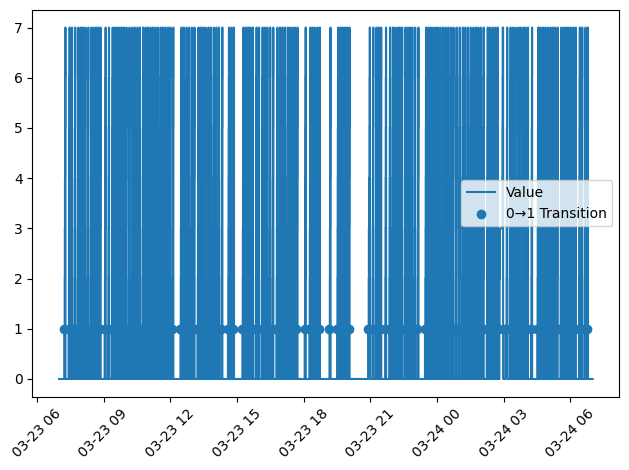

In [32]:
plt.figure()

# Full data
plt.step(df['Datetime'], df['Value'], label='Value')

# Mark transitions
plt.scatter(
    df.loc[df['Transition_0_to_1'], 'Datetime'],
    df.loc[df['Transition_0_to_1'], 'Value'],
    marker='o',
    label='0→1 Transition'
)

plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()